# Report

Questo notebook verrà utilizzato per mostrare passo passo l'analisi fatta a partire dai dati grezzi fino alla creazione dei modelli di forecasting e la valutazione di essi.

## Approccio utilizzato

> 1. Descriptive analysis
> 2. Preprocessing
> 3. Modelli statistici baseline
> 4. Modelli ML non neurali
> 5. Modelli neurali
> 6. Confronto prestazionale
> 7. Inferential statistics sui confronti
> 8. Prescriptive analytics 

NB_Gli step 3-4-5 comprenderanno anche la parte di parameter fitting.


## 1. Analisi descrittiva (step by step)

In questa sezione riportiamo, nello stesso ordine del codice Python, metriche e grafici già generati in `Results/` per la serie **Produzione lorda totale**.

### 1.0 Caricamento dei risultati


In [56]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Risoluzione robusta della root progetto
project_root = Path.cwd()
if not (project_root / "Results").exists() and (project_root.parent / "Results").exists():
    project_root = project_root.parent

metrics_dir = project_root / "Results" / "metrics"
plots_dir = project_root / "Results" / "plots" / "descriptive"

# Caricamento metriche generate dallo script principale
series_df = pd.read_csv(metrics_dir / "tavola_1_14_series_clean_v1.csv")
freq_df = pd.read_csv(metrics_dir / "tavola_1_14_frequency_distribution_v1.csv")
central_df = pd.read_csv(metrics_dir / "tavola_1_14_central_tendency_v1.csv")
dispersion_df = pd.read_csv(metrics_dir / "tavola_1_14_dispersion_measures_v1.csv")
outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_iqr_v1.csv")
outlier_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_summary_v1.csv")

print(f"Project root: {project_root}")
print(f"Rows in cleaned series: {len(series_df)}")

Project root: c:\Users\giann\Documents\GitHub\FinalProject
Rows in cleaned series: 131


### 1.1 Serie base

Visualizzazione della serie annuale (1883 in avanti) per capirne l'andamento con un primo approccio visivo

,year,produzione_lorda_totale
0,1883,1.0
1,1884,2.0
2,1885,3.0
3,1886,3.0
4,1887,4.0
5,1888,5.0
6,1889,6.0
7,1890,8.0
8,1891,15.0
9,1892,22.0


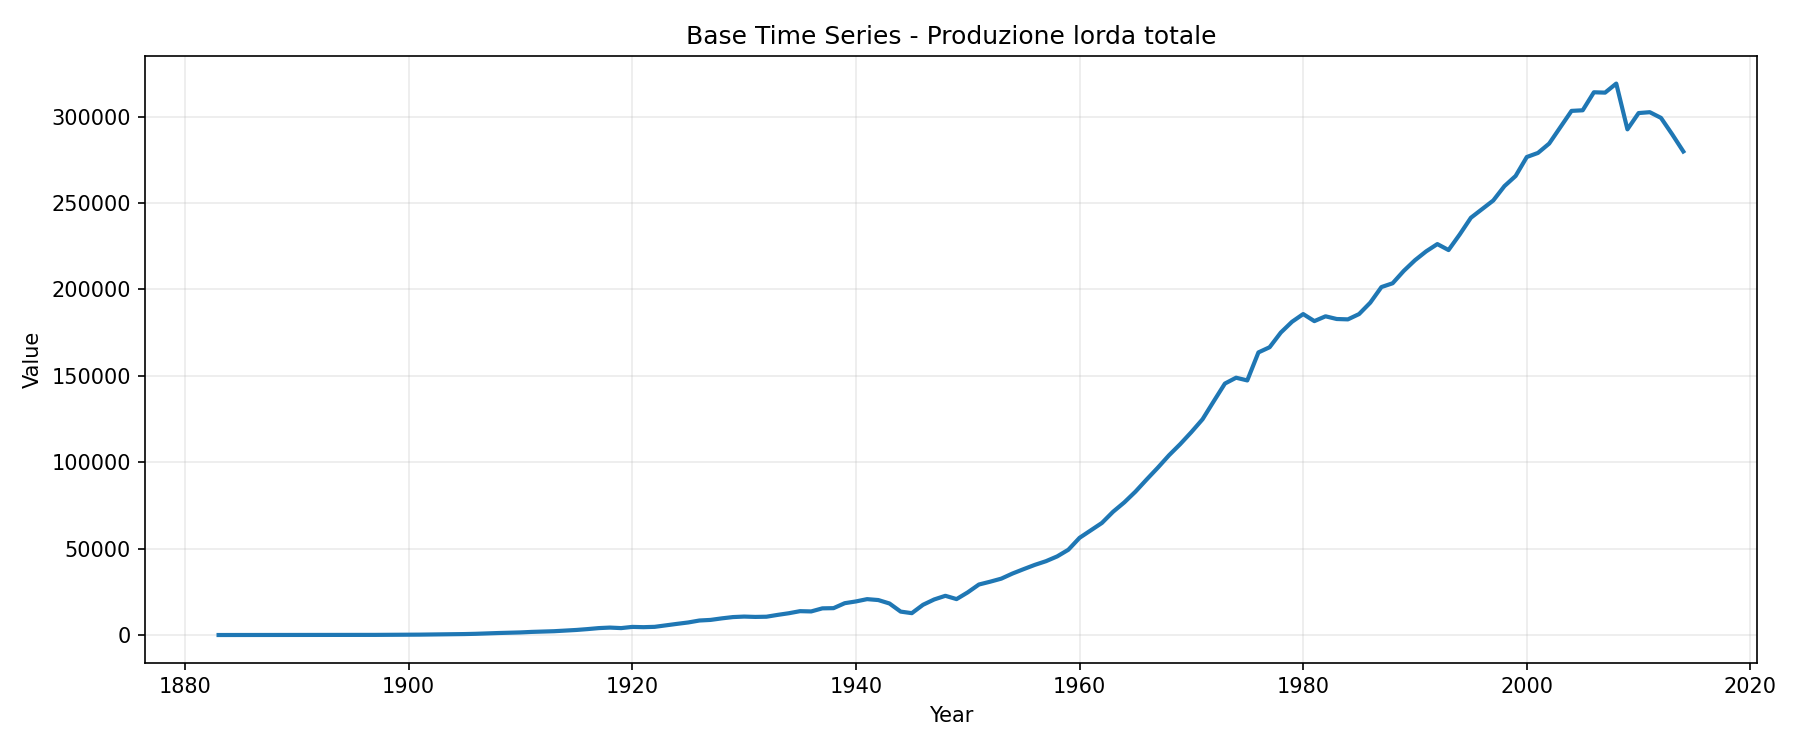

In [57]:
display(series_df.head(10))
display(Image(filename=str(plots_dir / "tavola_1_14_series_base_v1.png")))

### 1.2 Frequency distribution (empirica, relativa, bar chart)

La tabella seguente contiene le classi con frequenza assoluta e relativa.

,class_interval,absolute_frequency,relative_frequency
0,"(-318.13, 35459.778]",71,0.541985
1,"(35459.778, 70918.556]",9,0.068702
2,"(70918.556, 106377.333]",6,0.045802
3,"(106377.333, 141836.111]",4,0.030534
4,"(141836.111, 177294.889]",6,0.045802
5,"(177294.889, 212753.667]",11,0.083969
6,"(212753.667, 248212.444]",6,0.045802
7,"(248212.444, 283671.222]",6,0.045802
8,"(283671.222, 319130.0]",12,0.091603


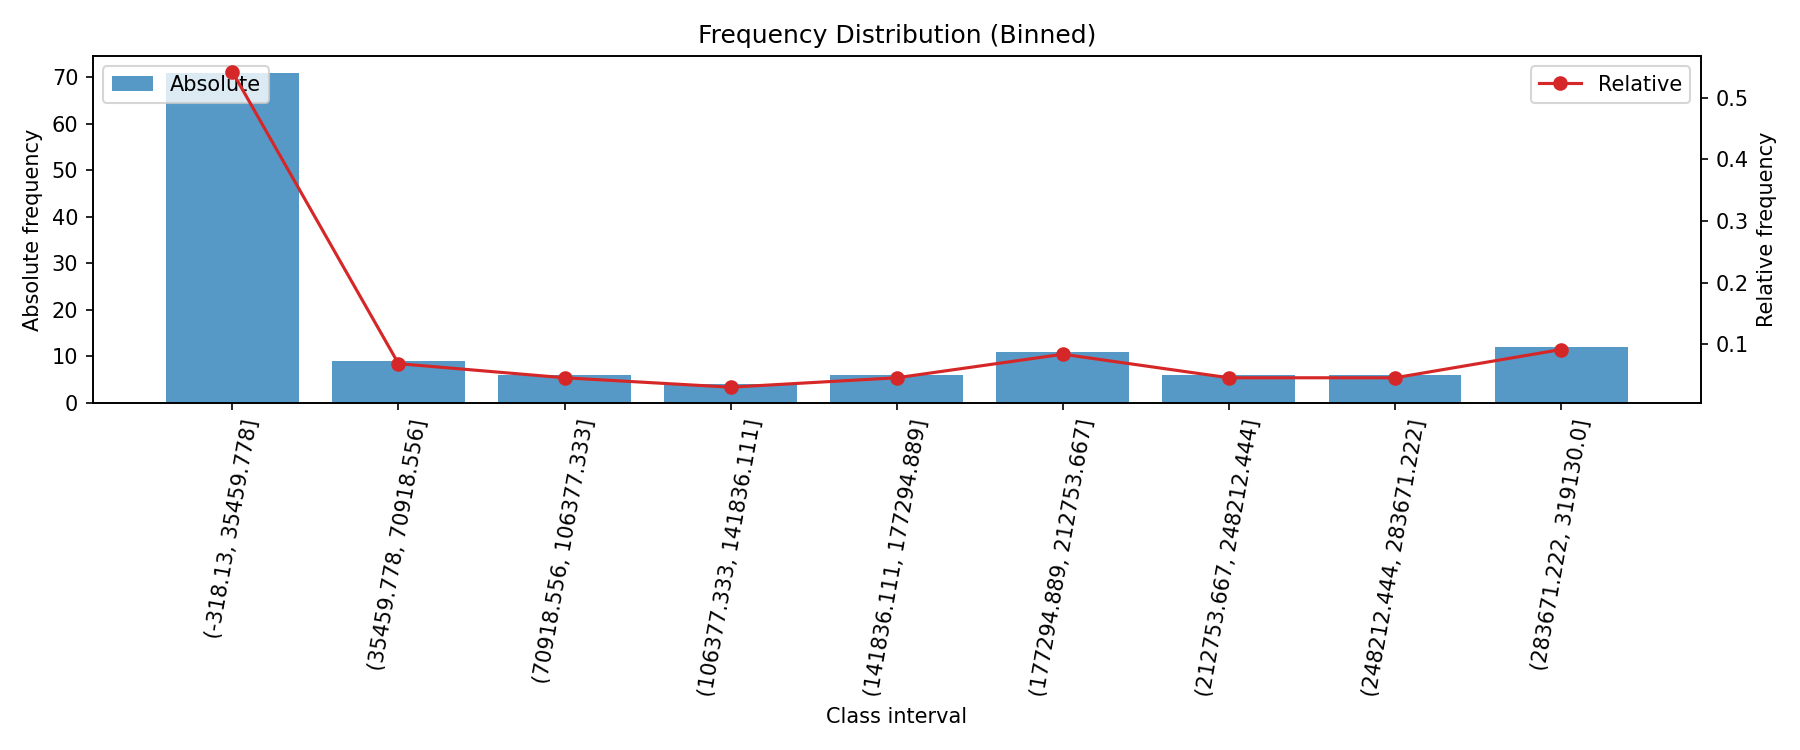

In [58]:
display(freq_df)
display(Image(filename=str(plots_dir / "tavola_1_14_frequency_distribution_v1.png")))

### 1.3 Central tendency e dispersion measures

Qui riportiamo media, mediana, moda, e poi range, varianza, deviazione standard, coefficiente di variazione e IQR.

In [59]:
display(central_df)
display(dispersion_df)

,mean,median,mode
0,88682.969466,20782.0,3.0


,range,variance,std_dev,coefficient_of_variation,iqr
0,319129.0,1.147613e+10,107126.719733,1.207974,178987.5


### 1.4 Outliers globali e studio della distribuzione

Outlier globali identificati con regola IQR sui livelli della serie. Per confronto coerente usiamo il boxplot sui livelli; in aggiunta mostriamo densita empirica vs fit normale/uniforme, distribuzione discreta e Q-Q plot.

,lower_fence,upper_fence,num_outliers,outlier_ratio
0,-265306.25,450643.75,0,0.0


,year,value


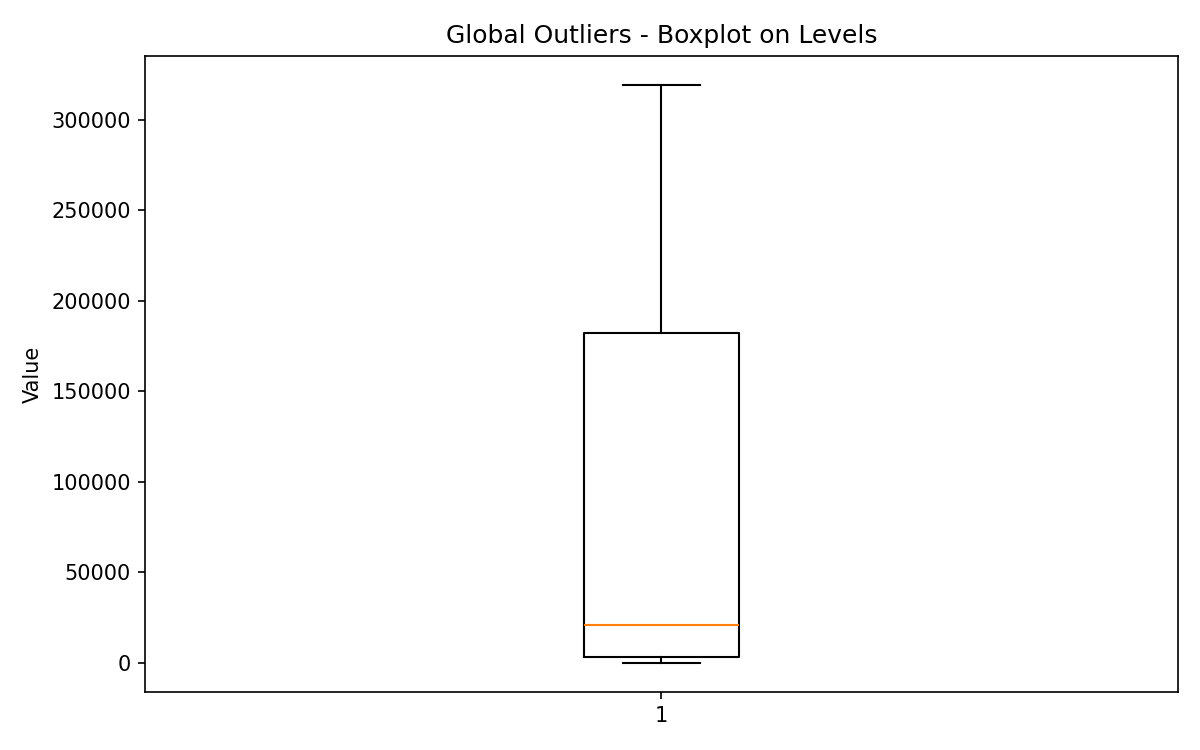

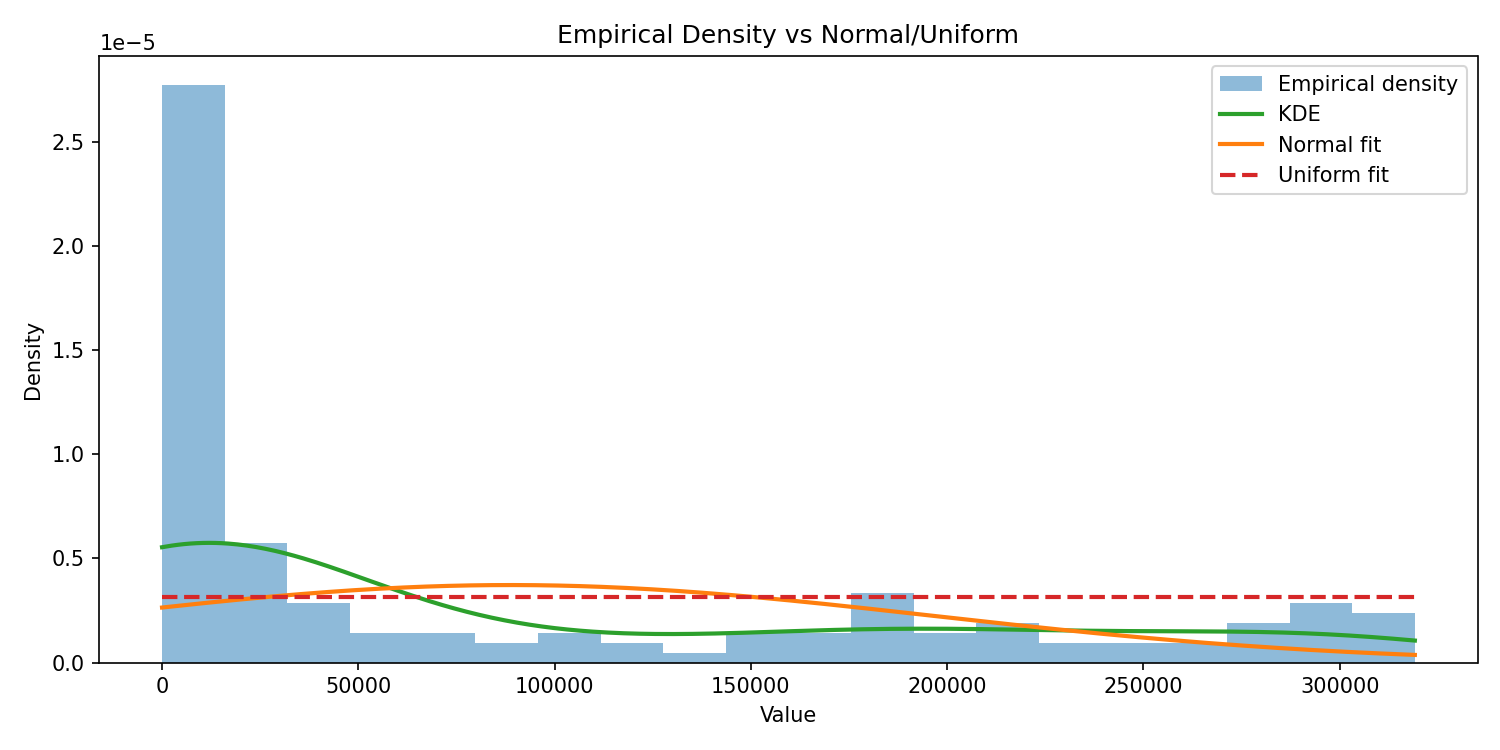

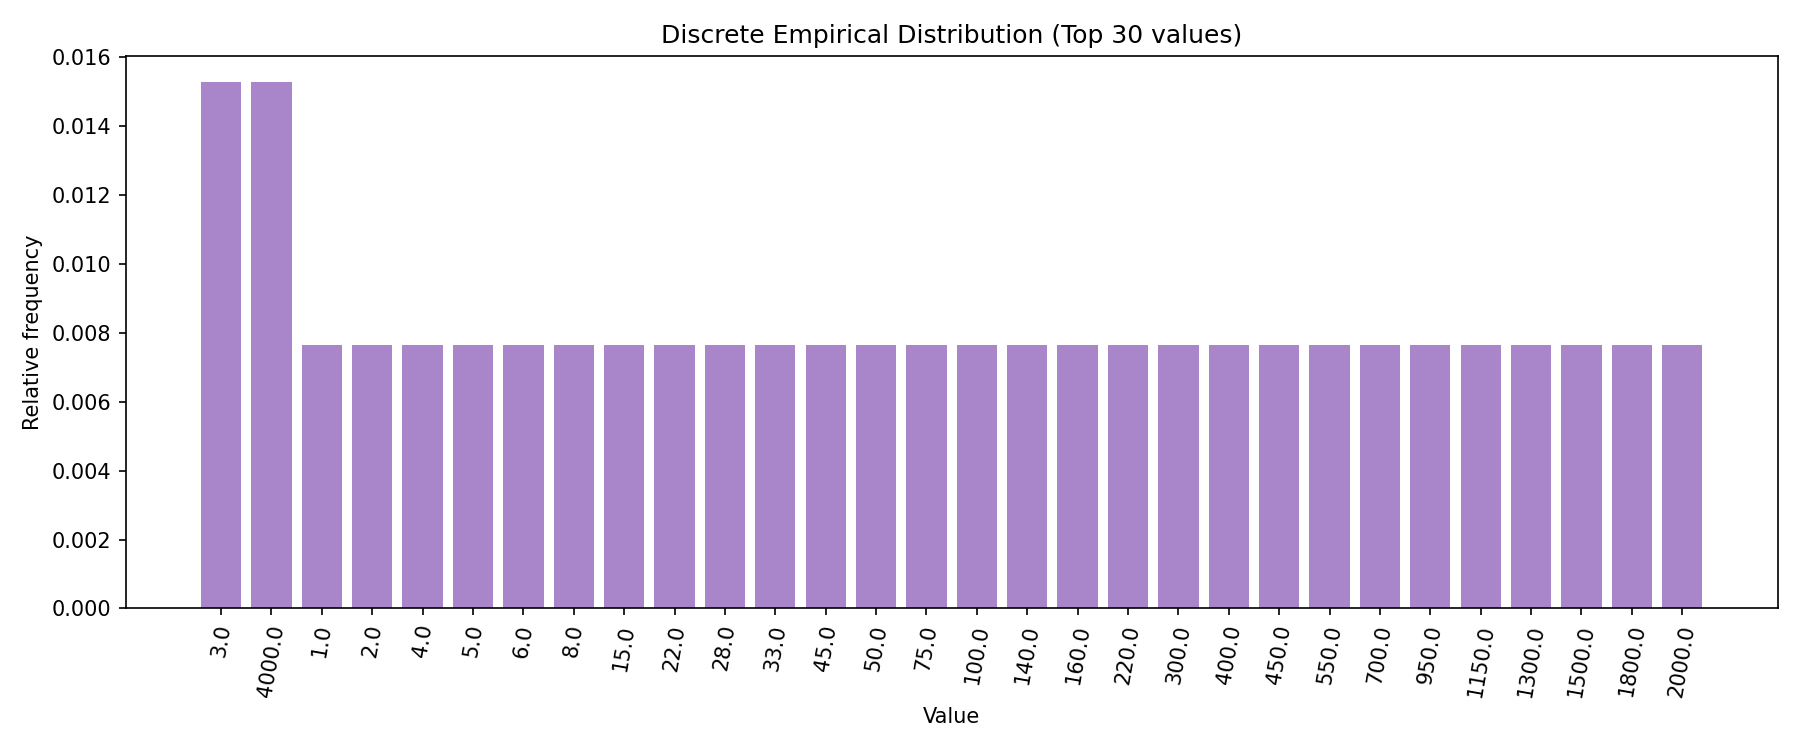

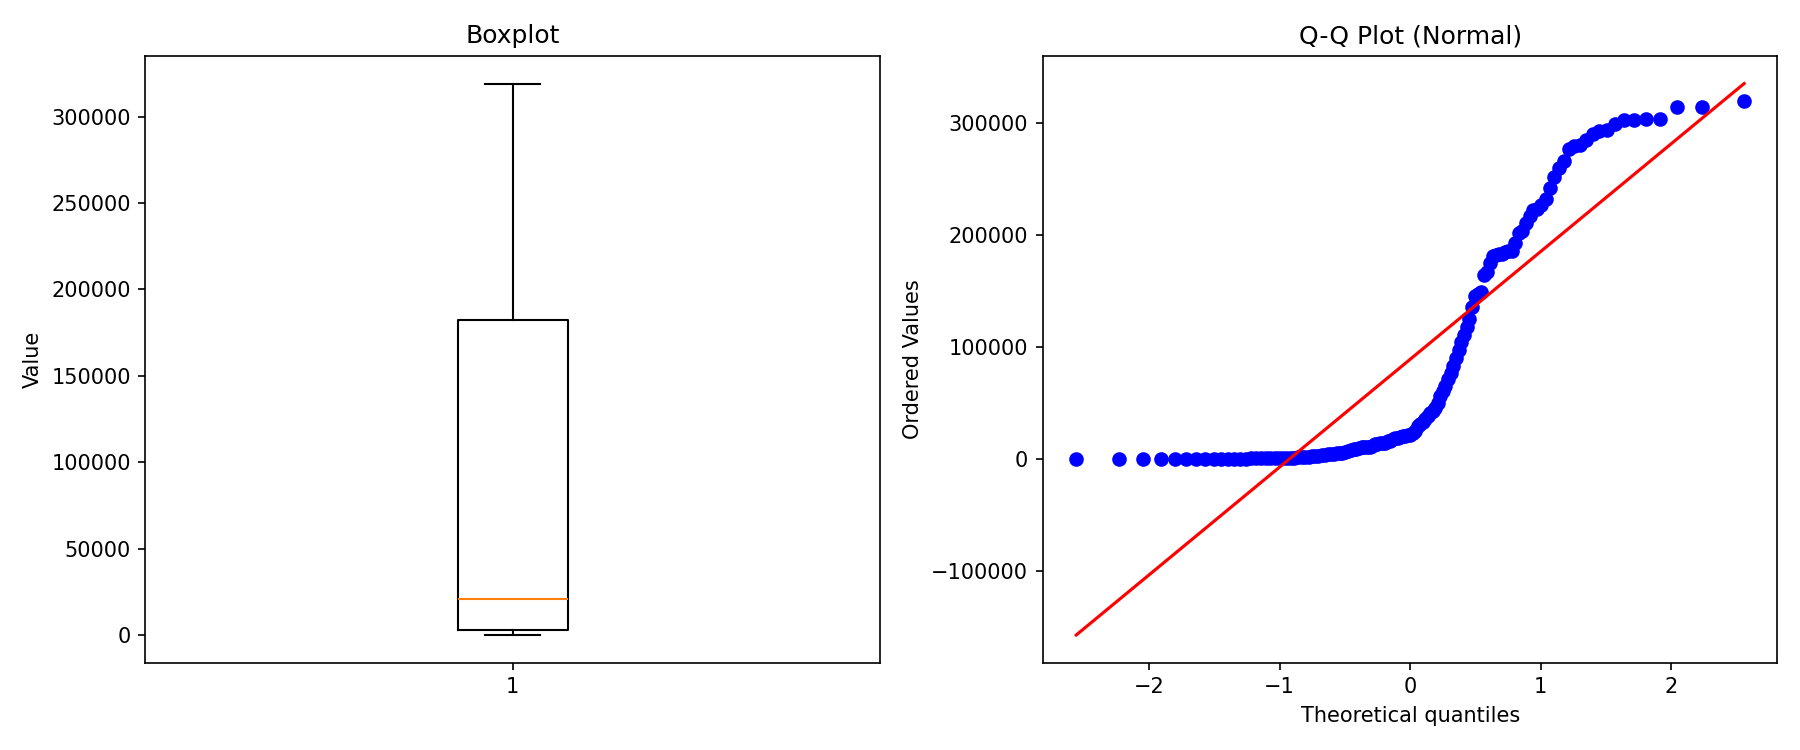

In [62]:
display(outlier_summary_df)
display(outliers_df.head(20))

# Stessa tipologia grafica usata anche per gli outlier locali (sezione 1.5)
display(Image(filename=str(plots_dir / "tavola_1_14_global_outliers_boxplot_v1.png")))

display(Image(filename=str(plots_dir / "tavola_1_14_density_comparison_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_discrete_distribution_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_outliers_qqplot_v1.png")))

### 1.5 Validazione numerica di trend crescente e anomalie locali

Per evitare che il trend globale nasconda variazioni anomale locali, analizziamo:

- trend lineare e correlazione con il tempo;
- variazioni anno su anno (YoY);
- outlier locali su YoY con baseline mobile (rolling median).

Per confronto omogeneo con la sezione 1.4, usiamo anche qui un boxplot (sulle variazioni YoY).

,n_observations,start_year,end_year,slope_per_year,slope_p_value,r_squared,spearman_rho,spearman_p_value,positive_yoy_share,negative_yoy_share,zero_yoy_share,intercept,slope_std_err
0,131,1883,2014,2548.968845,1.266610e-50,0.824752,0.997843,1.825742e-154,0.846154,0.146154,0.007692,-4.877059e+06,103.451136


,window,threshold,n_yoy_points,num_local_outliers,local_outlier_ratio,yoy_mean,yoy_std,yoy_q05,yoy_q95
0,11,3.5,130,2,0.015385,2152.523077,4700.087435,-2705.95,9580.6


,year,yoy_change,local_median_change,residual_vs_local,rolling_mad,local_score,is_local_outlier
0,1960,6890.0,4294.0,2596.0,256.0,6.839852,True
1,2009,-26488.0,351.0,-26839.0,5055.0,-3.581188,True


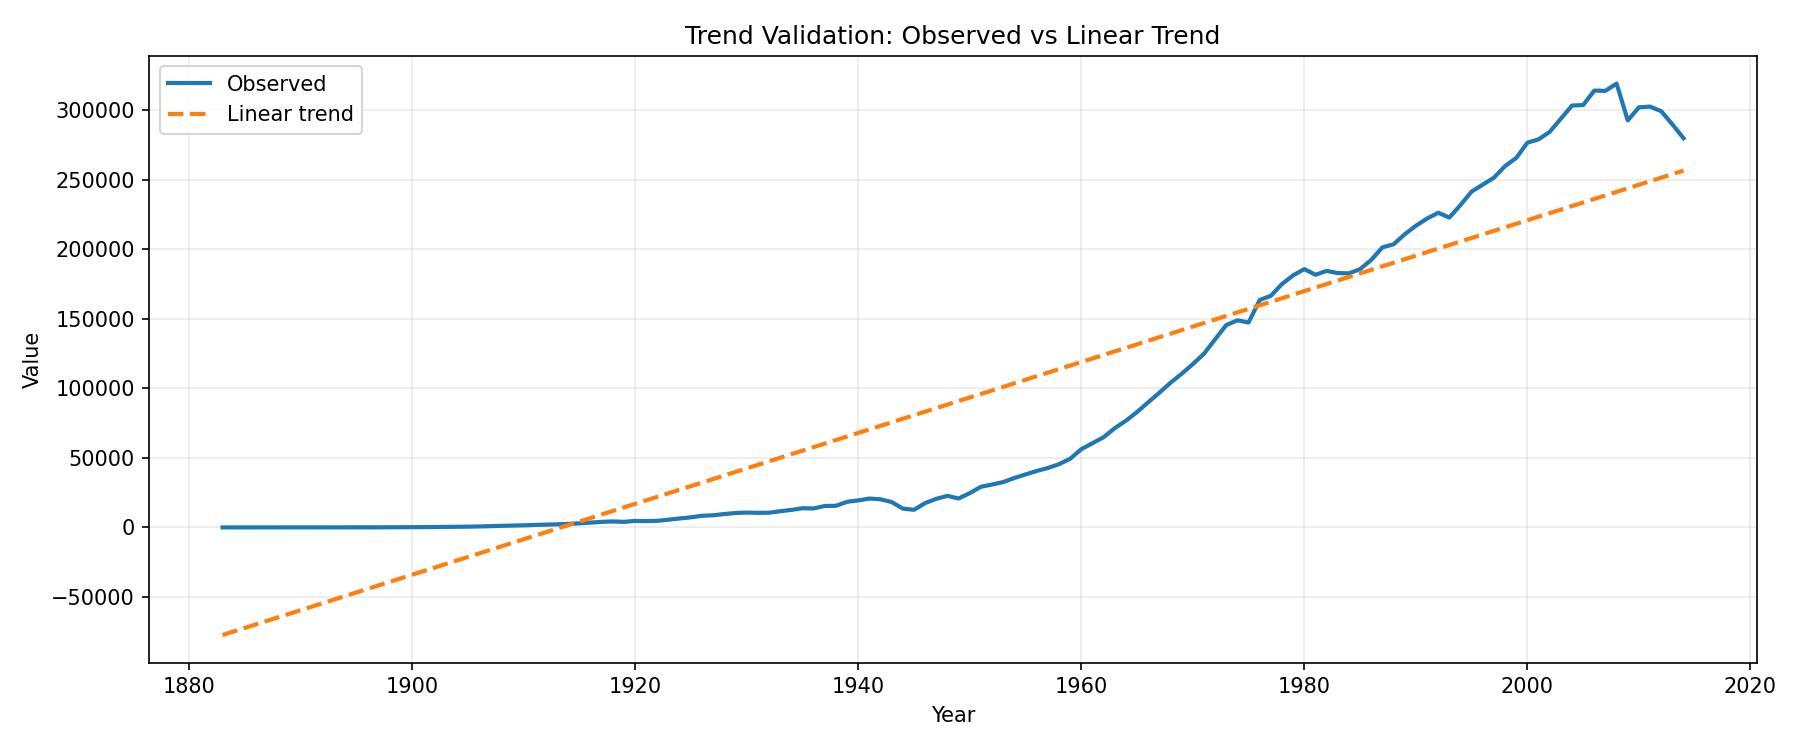

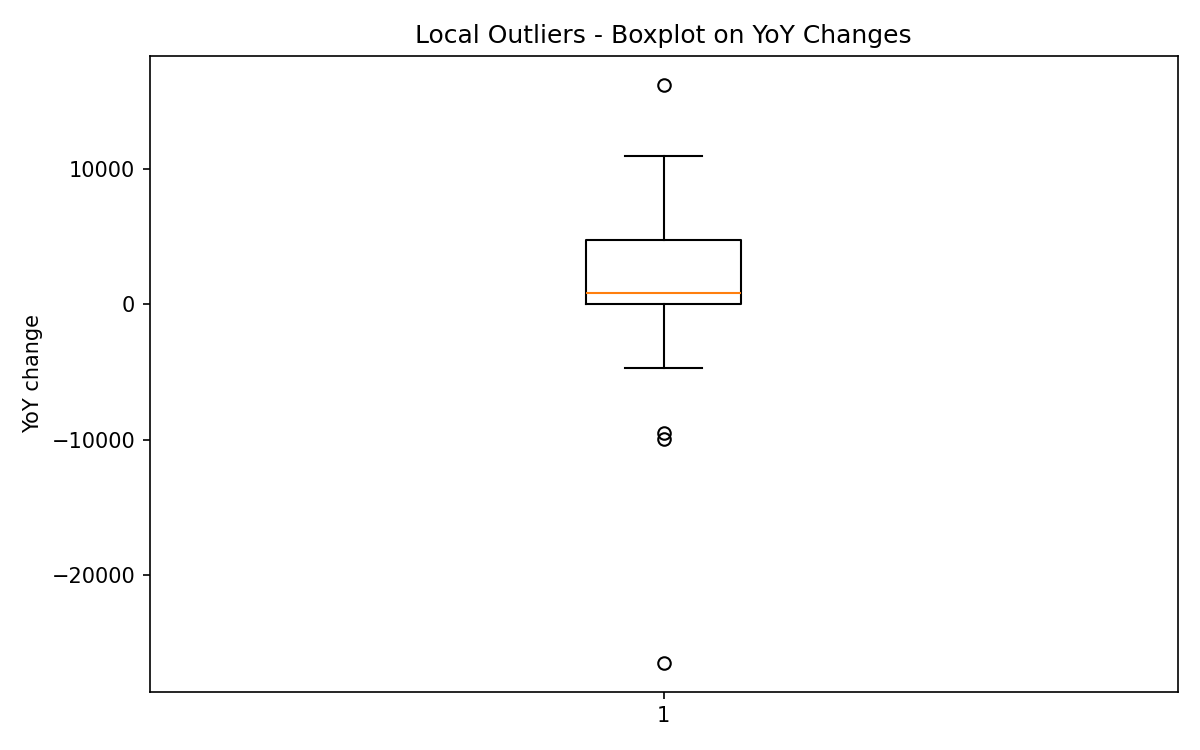

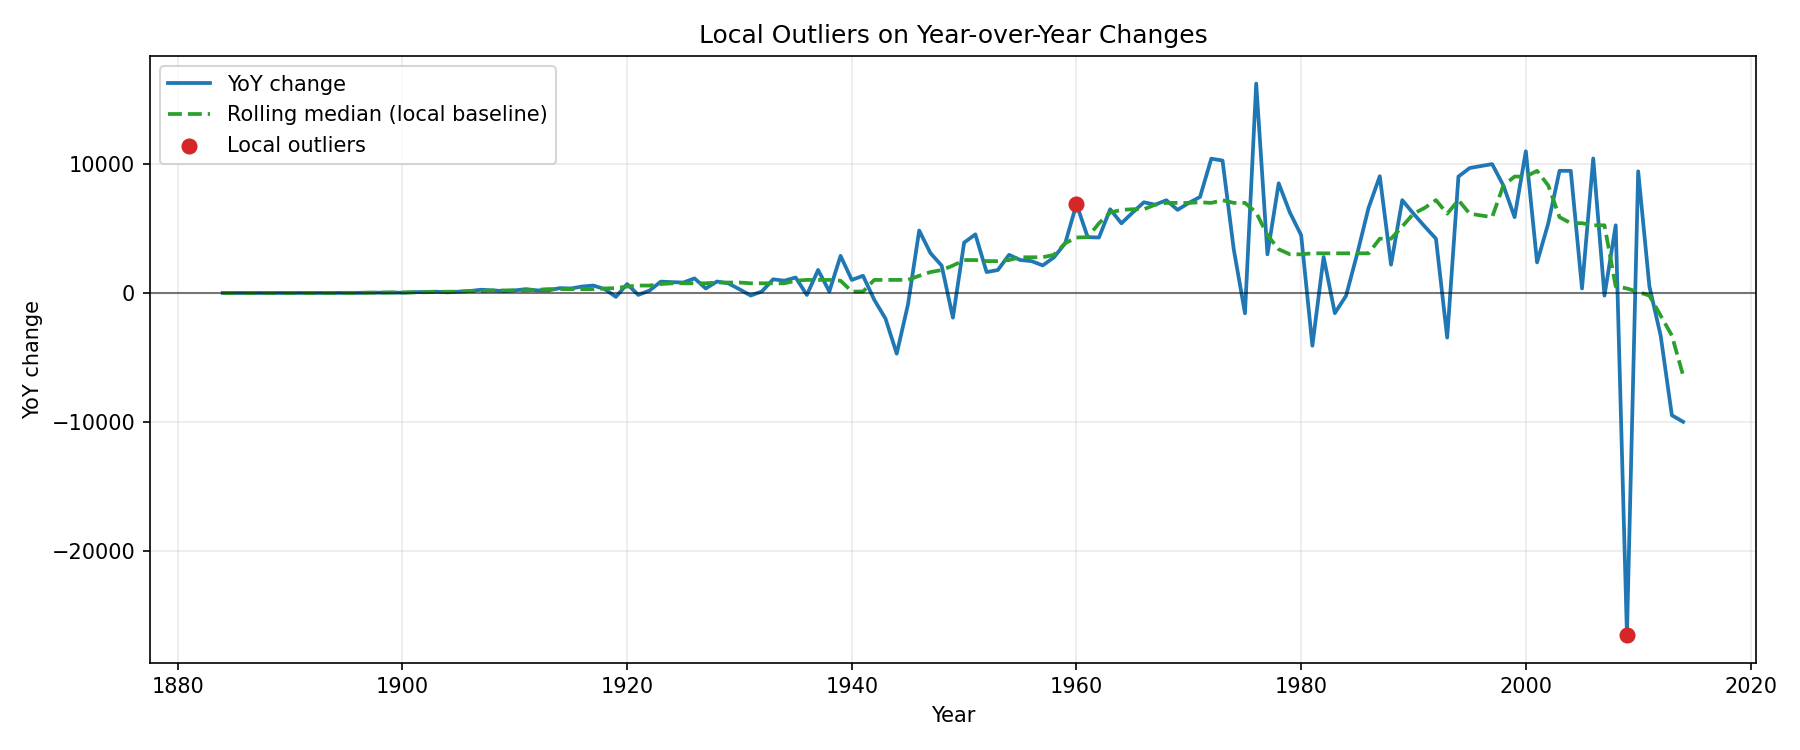

In [63]:
trend_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_trend_summary_v1.csv")
local_outliers_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_summary_v1.csv")
local_outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_yoy_v1.csv")

display(trend_summary_df)
display(local_outliers_summary_df)
display(local_outliers_df)

display(Image(filename=str(plots_dir / "tavola_1_14_trend_validation_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_boxplot_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_yoy_v1.png")))

### 1.6 Confronto tra analisi globale e locale

Il confronto tra le due analisi mostra che non ci sono outlier globali sui livelli (IQR), ma emergono poche anomalie locali quando si osservano le variazioni anno-su-anno rispetto a una baseline mobile. Questo risultato e coerente con una serie a trend crescente: i valori elevati negli anni recenti non sono necessariamente anomali in senso assoluto, mentre alcuni salti o crolli puntuali rappresentano shock locali. Di conseguenza, nella fase di preprocessing e preferibile trattare queste osservazioni come eventi specifici della dinamica temporale, evitando rimozioni automatiche basate solo su soglie globali.